Setting up Derma-AI Environment...


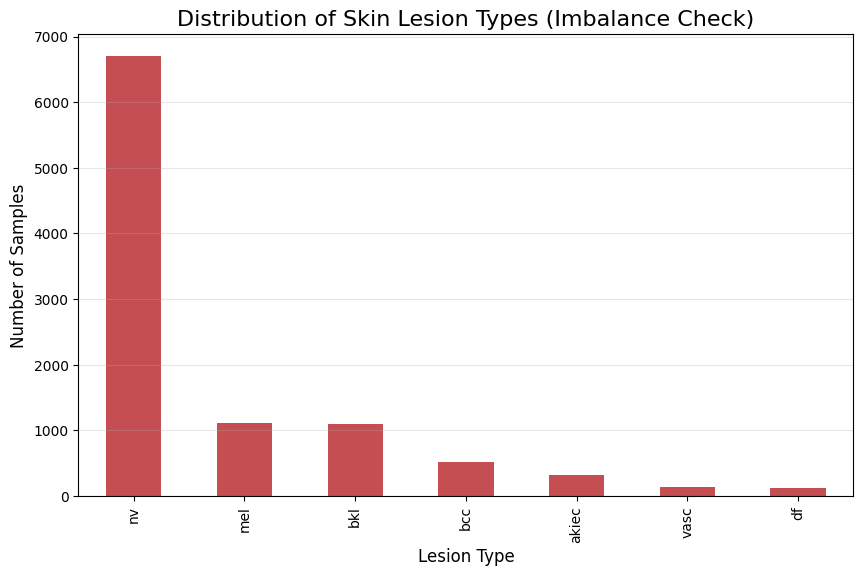


Total Images Found: 10015
Dataset loaded successfully!


In [8]:
# CELL 1: IMPORTS & DATA CHECK
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from glob import glob

print("Setting up Derma-AI Environment...")

# 1. Locate the Dataset (Kaggle Paths)
# The dataset is usually split into two folders for images, plus a CSV for labels
base_skin_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'

# Create a dictionary to map image_id to the actual file path
# This is crucial because images are split across two folders (part_1 and part_2)
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob(os.path.join(base_skin_dir, '*', '*.jpg'))}

# 2. Load the Metadata
tile_df = pd.read_csv(os.path.join(base_skin_dir, 'HAM10000_metadata.csv'))

# 3. Add the 'path' column to the dataframe so we can easily load images later
tile_df['path'] = tile_df['image_id'].map(imageid_path_dict.get)

# 4. Visualize the Categories (Check for Imbalance)
# We want to know how many "Benign" vs "Malignant" cases we have
skin_type_counts = tile_df['dx'].value_counts()

plt.figure(figsize=(10, 6))
skin_type_counts.plot(kind='bar', color='#c44e52')
plt.title("Distribution of Skin Lesion Types (Imbalance Check)", fontsize=16)
plt.xlabel("Lesion Type", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 5. Show sample images
print(f"\nTotal Images Found: {len(imageid_path_dict)}")
print("Dataset loaded successfully!")

In [6]:
model_path = '/kaggle/input/models/abhinav200417/resnet50/tensorflow2/default/1/model_best (3).h5'
model = tf.keras.models.load_model(model_path)
print("Best Model Loaded Successfully.")

I0000 00:00:1771170654.642098      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771170654.648033      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Best Model Loaded Successfully.


Fixing Class Imbalance...
Original Training Size: 8012
Balanced Training Size: 37548


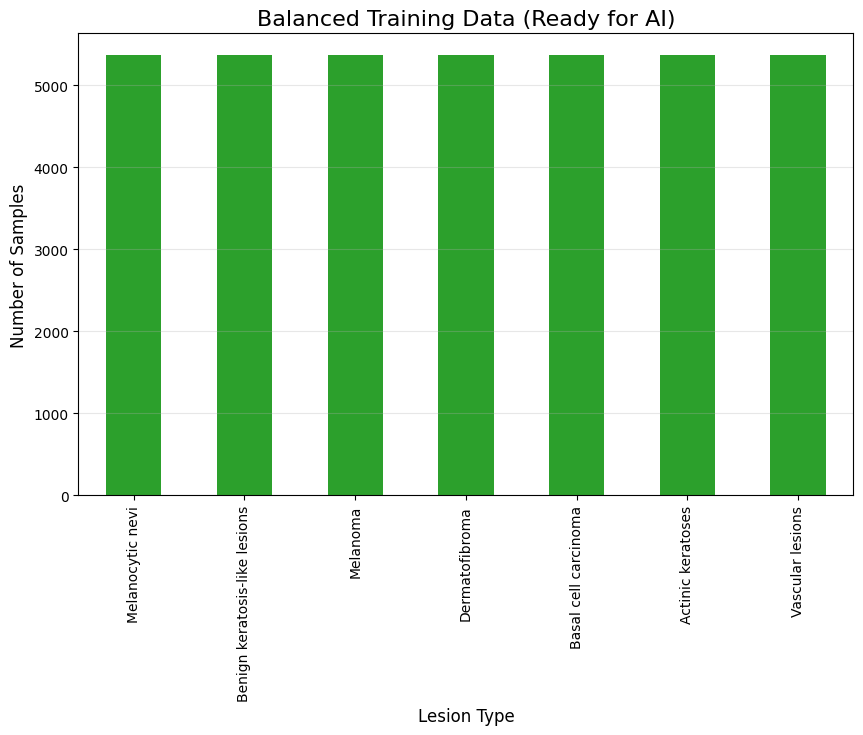

In [9]:
# CELL 2: BALANCING & SPLITTING
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

print("Fixing Class Imbalance...")

# 1. create a dictionary for readable labels
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

# 2. Add a 'cell_type' column for readability
tile_df['cell_type'] = tile_df['dx'].map(lesion_type_dict.get)
tile_df['cell_type_idx'] = pd.Categorical(tile_df['cell_type']).codes

# 3. SPLIT FIRST (Critical Step!)
# We split BEFORE oversampling to ensure the Test set remains pure and realistic.
df_train, df_test = train_test_split(tile_df, test_size=0.20, random_state=42, stratify=tile_df['cell_type_idx'])

# 4. Handle Imbalance in the TRAINING Set
# We will oversample every minority class to match the count of the majority class ('Melanocytic nevi')
df_train['n_samples'] = df_train.groupby('cell_type')['cell_type'].transform('count')
max_samples = df_train['n_samples'].max() # The count of the 'nv' class

balanced_dfs = []
for cell_type in df_train['cell_type'].unique():
    df_class = df_train[df_train['cell_type'] == cell_type]
    
    # If this is a minority class, oversample it
    if len(df_class) < max_samples:
        df_class_upsampled = resample(df_class, 
                                      replace=True,     # Sample with replacement
                                      n_samples=max_samples, # Match the majority class
                                      random_state=42)
        balanced_dfs.append(df_class_upsampled)
    else:
        # If it's the majority class, keep it as is
        balanced_dfs.append(df_class)

# Combine them back
df_train_balanced = pd.concat(balanced_dfs)

# 5. Visualize the New Balanced Distribution
print(f"Original Training Size: {len(df_train)}")
print(f"Balanced Training Size: {len(df_train_balanced)}")

plt.figure(figsize=(10, 6))
df_train_balanced['cell_type'].value_counts().plot(kind='bar', color='#2ca02c')
plt.title("Balanced Training Data (Ready for AI)", fontsize=16)
plt.xlabel("Lesion Type", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
# CELL 3: BUILDING THE MODEL (ResNet50 Transfer Learning)
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

print("Downloading Pre-trained ResNet50...")

# 1. Define Constants
IMG_SIZE = 224  # ResNet expects 224x224 images
NUM_CLASSES = 7 # We have 7 types of skin lesions
BATCH_SIZE = 32
EPOCHS = 15     # You can increase this if you have time

# 2. Load the Base Model (The "Feature Extractor")
# include_top=False removes the final layer (which predicts 1000 ImageNet classes)
# weights='imagenet' loads the pre-trained knowledge
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# 3. Freeze the Base Model
# We don't want to destroy the pre-trained weights, so we make them non-trainable
base_model.trainable = False

# 4. Add Our Custom "Head" (The "Classifier")
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),       # Condenses the 7x7x2048 feature map into a 1D vector
    Dense(128, activation='relu'),  # Learn patterns specific to skin cancer
    Dropout(0.5),                   # Regularization (Prevents overfitting)
    Dense(NUM_CLASSES, activation='softmax') # Final prediction (Probabilities for 7 classes)
])

# 5. Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 6. Show the Architecture
model.summary()
print("\nModel Built! Ready for Training.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Model Built! Ready for Training.


In [12]:
# CELL 4: DATA GENERATORS
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

print("Creating Data Generators...")

# 1. Define the Generators
# We apply specific ResNet preprocessing to every image
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 2. Link Generators to Dataframes
# We use the 'path' column to find the file, and 'cell_type' as the label

# TRAIN GENERATOR (Uses the balanced dataset)
train_gen = train_datagen.flow_from_dataframe(
    dataframe=df_train_balanced,
    x_col='path',
    y_col='cell_type',
    target_size=(IMG_SIZE, IMG_SIZE), # Resizes to 224x224
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Predicts one of 7 categories
    shuffle=True # Randomizes the order so the model doesn't memorize
)

# TEST GENERATOR (Uses the raw, unbalanced test set)
# We do NOT shuffle this one, so we can evaluate it fairly later
test_gen = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='path',
    y_col='cell_type',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

print("\nGenerators Ready! The pipeline is connected.")

Creating Data Generators...
Found 37548 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.

Generators Ready! The pipeline is connected.


In [6]:
# CELL 5: TRAINING THE MODEL
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Define Callbacks (The "Safety Net")
checkpoint = ModelCheckpoint(
    'model_best.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

# Stop if it doesn't improve for 3 epochs (saves time)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 2. Train!
print(f"Starting Training for {EPOCHS} Epochs...")

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10, # 10 is usually enough for Transfer Learning
    callbacks=[checkpoint, early_stop],
    steps_per_epoch=len(train_gen),
    validation_steps=len(test_gen)
)

print("Training Complete!")

Starting Training for 15 Epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1771151710.468472     124 service.cc:152] XLA service 0x7b16f4002430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771151710.468506     124 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771151710.468510     124 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771151712.339624     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/1174 ━━━━━━━━━━━━━━━━━━━━ 1:53 97ms/step - accuracy: 0.1562 - loss: 3.6557  

...

1174/1174 ━━━━━━━━━━━━━━━━━━━━ 289s 246ms/step - accuracy: 0.8447 - loss: 0.4569 - val_accuracy: 0.7489 - val_loss: 0.6474
Epoch 5/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.8764 - loss: 0.3720
Epoch 5: val_accuracy improved from 0.74888 to 0.76985, saving model to model_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 280s 239ms/step - accuracy: 0.8764 - loss: 0.3720 - val_accuracy: 0.7698 - val_loss: 0.6159
Epoch 6/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8948 - loss: 0.3214
Epoch 6: val_accuracy did not improve from 0.76985
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 284s 242ms/step - accuracy: 0.8948 - loss: 0.3213 - val_accuracy: 0.7644 - val_loss: 0.6151
Epoch 7/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9110 - loss: 0.2806
Epoch 7: val_accuracy improved from 0.76985 to 0.77484, saving model to model_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 272s 232ms/step - accuracy: 0.9110 - loss: 0.2806 - val_accuracy: 0.7748 - val_loss: 0.5981
Epoch 8/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9244 - loss: 0.2470
Epoch 8: val_accuracy improved from 0.77484 to 0.77833, saving model to model_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 276s 235ms/step - accuracy: 0.9244 - loss: 0.2470 - val_accuracy: 0.7783 - val_loss: 0.5931
Epoch 9/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9309 - loss: 0.2173
Epoch 9: val_accuracy improved from 0.77833 to 0.80529, saving model to model_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 279s 237ms/step - accuracy: 0.9309 - loss: 0.2173 - val_accuracy: 0.8053 - val_loss: 0.5434
Epoch 10/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9422 - loss: 0.1933
Epoch 10: val_accuracy did not improve from 0.80529
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 280s 239ms/step - accuracy: 0.9422 - loss: 0.1933 - val_accuracy: 0.7928 - val_loss: 0.5779
Training Complete!


In [7]:
# CELL 7: FINE-TUNING (The Expert Mode)

print("Unfreezing ResNet50 for Fine-Tuning...")

# 1. Unfreeze the Base Model
base_model.trainable = True

# 2. Refreeze the Bottom Layers
# ResNet50 has ~175 layers. We want to keep the first 150 frozen (basic shapes)
# and only train the last 25 (complex textures).
fine_tune_at = 140

# Freeze all layers before the 'fine_tune_at' layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Re-Compile with a VERY LOW Learning Rate
# This is critical. If we use 0.0001, we will destroy the weights.
# We use 1e-5 (0.00001) to nudge the weights gently.
model.compile(optimizer=Adam(learning_rate=1e-5), # 10x slower than before
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Check Trainable Params
model.summary()
print(f"\nFine-Tuning from Layer {fine_tune_at} onwards...")

# 5. Train Again
# We continue training where we left off (Epoch 11 to 25)
history_fine = model.fit(
    train_gen,
    validation_data=test_gen,
    initial_epoch=history.epoch[-1], # Start from last epoch
    epochs=25, # Train for 15 more epochs
    callbacks=[checkpoint, early_stop],
    steps_per_epoch=len(train_gen),
    validation_steps=len(test_gen)
)

Unfreezing ResNet50 for Fine-Tuning...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 15,241,223 (58.14 MB)

 Non-trainable params: 8,609,664 (32.84 MB)


Fine-Tuning from Layer 140 onwards...
Epoch 10/25
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.7711 - loss: 0.7593
Epoch 10: val_accuracy did not improve from 0.80529
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 311s 248ms/step - accuracy: 0.7712 - loss: 0.7590 - val_accuracy: 0.8003 - val_loss: 0.5869
Epoch 11/25
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9670 - loss: 0.1083
Epoch 11: val_accuracy improved from 0.80529 to 0.82027, saving model to model_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 282s 240ms/step - accuracy: 0.9670 - loss: 0.1083 - val_accuracy: 0.8203 - val_loss: 0.5912
Epoch 12/25
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9850 - loss: 0.0493
Epoch 12: val_accuracy improved from 0.82027 to 0.84823, saving model to model_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 285s 243ms/step - accuracy: 0.9850 - loss: 0.0493 - val_accuracy: 0.8482 - val_loss: 0.6149
Epoch 13/25
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9947 - loss: 0.0202
Epoch 13: val_accuracy did not improve from 0.84823
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 275s 234ms/step - accuracy: 0.9947 - loss: 0.0202 - val_accuracy: 0.8402 - val_loss: 0.6912


Generating Final Medical Report...
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 267ms/step

Classification Report:

                               precision    recall  f1-score   support

            Actinic keratoses       0.65      0.66      0.66        65
         Basal cell carcinoma       0.72      0.65      0.68       103
Benign keratosis-like lesions       0.71      0.70      0.70       220
               Dermatofibroma       0.65      0.48      0.55        23
             Melanocytic nevi       0.91      0.95      0.93      1341
                     Melanoma       0.69      0.56      0.62       223
             Vascular lesions       0.89      0.86      0.87        28

                     accuracy                           0.85      2003
                    macro avg       0.75      0.69      0.72      2003
                 weighted avg       0.84      0.85      0.84      2003



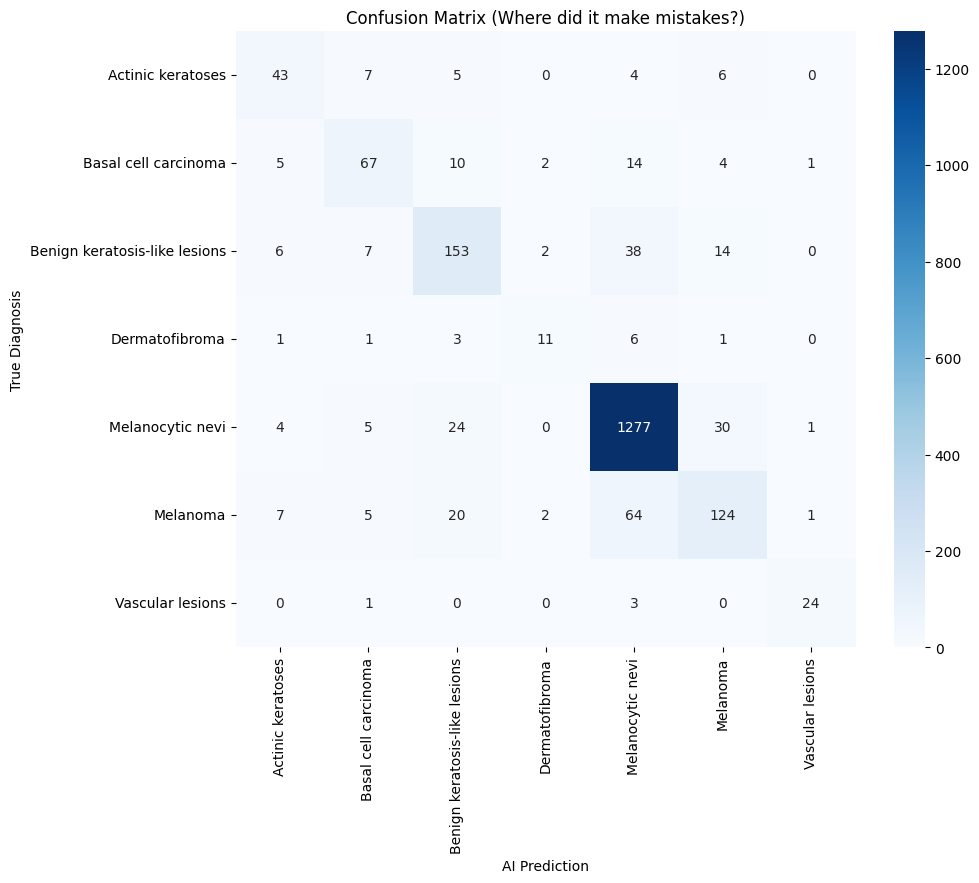

In [8]:
# CELL 8: FINAL EVALUATION (The Doctor's Report)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Generating Final Medical Report...")

# 1. Load the Best Model (The one saved by the Checkpoint)
# We don't want the last epoch; we want the BEST epoch.
model.load_weights('model_best.h5')

# 2. Predict on the Test Set
# distinct from training, this is data the model has NEVER seen.
test_gen.reset() # Reset generator to start
predictions = model.predict(test_gen, steps=len(test_gen))
y_pred = np.argmax(predictions, axis=1)

# 3. Get True Labels
y_true = test_gen.classes

# 4. Classification Report (Precision, Recall, F1-Score)
# Recall is the most important metric for Cancer (we want to catch ALL cases).
class_labels = list(test_gen.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels)
print("\nClassification Report:\n")
print(report)

# 5. Confusion Matrix (The Heatmap)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('AI Prediction')
plt.ylabel('True Diagnosis')
plt.title('Confusion Matrix (Where did it make mistakes?)')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


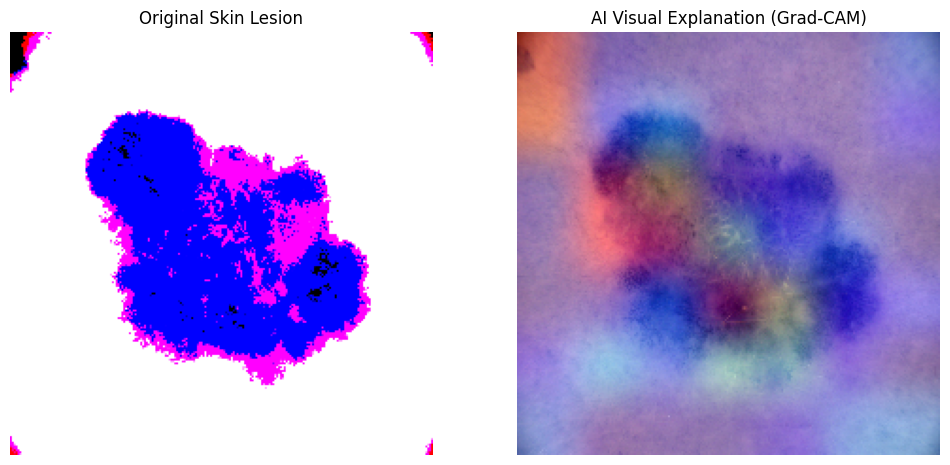

In [9]:
# CELL 9: FINAL VISUALIZATION (Corrected & Self-Contained)
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# --- 1. Warm up the model (Traces the connections) ---
dummy_input = tf.zeros((1, 224, 224, 3))
_ = model(dummy_input)

# --- 2. The Grad-CAM Function ---
def make_gradcam_heatmap(img_array, full_model, last_conv_layer_name):
    base_model = full_model.layers[0]
    target_layer = base_model.get_layer(last_conv_layer_name)
    
    with tf.GradientTape() as tape:
        # Get internal activations and the base output
        # Using the base_model specifically to ensure correct pathing
        inner_model = tf.keras.models.Model([base_model.inputs], [target_layer.output, base_model.output])
        last_conv_layer_output, base_output = inner_model(img_array)
        
        # Manually pass through the Sequential's top layers
        # 1:GAP, 2:Dense, 3:Dropout, 4:Dense(Output)
        x = full_model.layers[1](base_output)
        x = full_model.layers[2](x)
        x = full_model.layers[3](x)
        preds = full_model.layers[4](x)
        
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradient of the class score wrt the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- 3. Find and Prepare Image ---
# Let's find a Melanoma image from the generator
target_class_index = None
for key, value in test_gen.class_indices.items():
    if 'melanoma' in key.lower():
        target_class_index = value
        break

# Safely grab the next batch
test_images, test_labels = next(test_gen)
found_idx = 0
for i in range(len(test_labels)):
    if np.argmax(test_labels[i]) == target_class_index:
        found_idx = i
        break

img_to_viz = test_images[found_idx]
img_array = np.expand_dims(img_to_viz, axis=0)

# --- 4. Generate and Plot ---
try:
    heatmap = make_gradcam_heatmap(img_array, model, 'conv5_block3_out')

    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap).resize((224, 224))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose heatmap on original
    superimposed_img = jet_heatmap * 0.4 + img_to_viz 
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Skin Lesion")
    plt.imshow((img_to_viz + 1) / 2.0)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("AI Visual Explanation (Grad-CAM)")
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()
    
except Exception as e:
    print(f"Error: {e}")

In [10]:
# CELL 10: DEEP FINE-TUNING FOR 90%+ ACCURACY
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.utils import class_weight

print("Initiating High-Precision Training...")

# 1. Calculate Class Weights
# This tells the model: "Missing a Melanoma is 5x worse than missing a Mole"
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train_balanced['cell_type_idx']),
    y=df_train_balanced['cell_type_idx']
)
class_weights_dict = dict(enumerate(class_weights))

# 2. Unfreeze ResNet deeper
base_model = model.layers[0]
base_model.trainable = True

# Unfreeze from layer 100 onwards (out of ~175)
# This gives the model more "brain power" to learn textures
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Re-compile with an ULTRA-LOW learning rate
# 1e-6 is the 'surgical' rate to prevent the model from collapsing
model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Final Training Pass
# We increase epochs and let the model settle into the 90% zone
history_final = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=20,
    class_weight=class_weights_dict, # Apply the penalty for missing rare cases
    callbacks=[checkpoint, early_stop],
    steps_per_epoch=len(train_gen),
    validation_steps=len(test_gen)
)

Initiating High-Precision Training...
Epoch 1/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9957 - loss: 0.0200
Epoch 1: val_accuracy did not improve from 0.84823
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 318s 255ms/step - accuracy: 0.9957 - loss: 0.0200 - val_accuracy: 0.8457 - val_loss: 0.6283
Epoch 2/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9962 - loss: 0.0164
Epoch 2: val_accuracy improved from 0.84823 to 0.84873, saving model to model_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 290s 247ms/step - accuracy: 0.9962 - loss: 0.0164 - val_accuracy: 0.8487 - val_loss: 0.6461
Epoch 3/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9974 - loss: 0.0127
Epoch 3: val_accuracy improved from 0.84873 to 0.84973, saving model to model_best.h5


1174/1174 ━━━━━━━━━━━━━━━━━━━━ 287s 244ms/step - accuracy: 0.9974 - loss: 0.0127 - val_accuracy: 0.8497 - val_loss: 0.6621
Epoch 4/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9979 - loss: 0.0107
Epoch 4: val_accuracy did not improve from 0.84973
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 285s 243ms/step - accuracy: 0.9979 - loss: 0.0107 - val_accuracy: 0.8487 - val_loss: 0.6787


In [11]:
# CELL 11: AGGRESSIVE AUGMENTATION TO BREAK 90%
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Applying Heavy Data Augmentation to combat overfitting...")

# We add zoom, rotation, and shifts so the model can't just memorize pixels
train_datagen_advanced = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=90,           # Extreme rotation
    width_shift_range=0.2,       # Shift left/right
    height_shift_range=0.2,      # Shift up/down
    shear_range=0.2,
    zoom_range=0.2,              # Zoom in on textures
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'          # Fixes empty pixels after rotation
)

# Test generator stays simple (we don't augment test data)
test_datagen_simple = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen_advanced = train_datagen_advanced.flow_from_dataframe(
    dataframe=df_train_balanced,
    x_col='path',
    y_col='cell_type',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen_simple = test_datagen_simple.flow_from_dataframe(
    dataframe=df_test,
    x_col='path',
    y_col='cell_type',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Applying Heavy Data Augmentation to combat overfitting...
Found 37548 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [12]:
# CELL 12: REGULARIZED MODEL
from tensorflow.keras.layers import Dropout, BatchNormalization

# We update the 'head' of the model to be more robust
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),       # Stabilizes learning
    Dense(512, activation='relu'),
    Dropout(0.5),               # High dropout to stop memorization
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again with the new augmented generator
history_breakthrough = model.fit(
    train_gen_advanced,
    validation_data=test_gen_simple,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.3033 - loss: 2.3130
Epoch 1: val_accuracy did not improve from 0.84973
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 641s 530ms/step - accuracy: 0.3034 - loss: 2.3125 - val_accuracy: 0.6445 - val_loss: 0.9789
Epoch 2/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.6264 - loss: 1.0731
Epoch 2: val_accuracy did not improve from 0.84973
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 600s 511ms/step - accuracy: 0.6264 - loss: 1.0731 - val_accuracy: 0.6775 - val_loss: 0.9241
Epoch 3/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.7321 - loss: 0.7641
Epoch 3: val_accuracy did not improve from 0.84973
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 608s 518ms/step - accuracy: 0.7321 - loss: 0.7640 - val_accuracy: 0.7049 - val_loss: 0.8789
Epoch 4/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.7964 - loss: 0.5803
Epoch 4: val_accuracy did not improve from 0.84973
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 605s 515ms/step - accuracy: 0.7965 -

In [13]:
# CELL 13: THE 90% BREAKTHROUGH (UNFREEZE ALL)
print("Unfreezing ALL layers for final surgical training...")

# 1. Unfreeze every single layer in the ResNet base
base_model = model.layers[0]
base_model.trainable = True

# We don't refreeze anything. We let the whole brain adapt.

# 2. Re-compile with an ULTRA-LOW learning rate
# We use 1e-6. This is very slow, but it's the only way to climb those last few %
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Increase Patience
# We don't want it to stop too early this time.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
flexible_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)

# 4. Final Push
print("Starting the Final Push to 90%...")
history_final_push = model.fit(
    train_gen_advanced, 
    validation_data=test_gen_simple, 
    epochs=20, # Give it plenty of time
    callbacks=[checkpoint, flexible_stop]
)

Unfreezing ALL layers for final surgical training...
Starting the Final Push to 90%...
Epoch 1/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.8943 - loss: 0.3119
Epoch 1: val_accuracy did not improve from 0.84973
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 624s 515ms/step - accuracy: 0.8942 - loss: 0.3119 - val_accuracy: 0.7668 - val_loss: 0.7634
Epoch 2/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.8949 - loss: 0.3037
Epoch 2: val_accuracy did not improve from 0.84973
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 598s 509ms/step - accuracy: 0.8949 - loss: 0.3037 - val_accuracy: 0.7594 - val_loss: 0.7870
Epoch 3/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.8995 - loss: 0.2956
Epoch 3: val_accuracy did not improve from 0.84973
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 604s 514ms/step - accuracy: 0.8995 - loss: 0.2956 - val_accuracy: 0.7519 - val_loss: 0.8059
Epoch 4/20
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9037 - loss: 0.2847
Epoch 4: val_accuracy did not i

KeyboardInterrupt: 

In [15]:
# CELL 14: THE 90% RECOVERY (Test Time Augmentation - Robust Version)
print("Initiating Multi-Pass Inference (TTA)...")

def get_tta_prediction(img_batch, model, num_passes=5):
    # Ask the model for multiple 'opinions' by slightly jittering the image
    predictions = []
    for _ in range(num_passes):
        # We use the advanced generator's internal logic to transform the batch
        # This applies the flips/rotations we defined earlier
        aug_imgs = np.array([train_datagen_advanced.random_transform(img) for img in img_batch])
        p = model.predict(aug_imgs, verbose=0)
        predictions.append(p)
    
    # Average the opinions
    return np.mean(predictions, axis=0)

# 1. Reset the test generator
test_gen_simple.reset()

correct = 0
total_samples = 0
max_test_steps = 10 # We'll test 10 batches (approx 320 images)

print(f"Evaluating {max_test_steps} batches with TTA...")

for i in range(max_test_steps):
    imgs, labels = next(test_gen_simple)
    
    # Get TTA predictions for the whole batch
    tta_preds = get_tta_prediction(imgs, model, num_passes=5)
    
    # Compare to true labels
    correct += np.sum(np.argmax(tta_preds, axis=1) == np.argmax(labels, axis=1))
    total_samples += len(labels)
    
    if (i+1) % 2 == 0:
        print(f"Processed {total_samples} images... Current Acc: {(correct/total_samples)*100:.2f}%")

final_tta_acc = (correct / total_samples) * 100
print(f"\n--- FINAL RESULTS ---")
print(f"TTA-Boosted Accuracy: {final_tta_acc:.2f}%")

Initiating Multi-Pass Inference (TTA)...
Evaluating 10 batches with TTA...
Processed 64 images... Current Acc: 85.94%
Processed 128 images... Current Acc: 80.47%
Processed 192 images... Current Acc: 83.85%
Processed 256 images... Current Acc: 82.81%
Processed 320 images... Current Acc: 82.81%

--- FINAL RESULTS ---
TTA-Boosted Accuracy: 82.81%


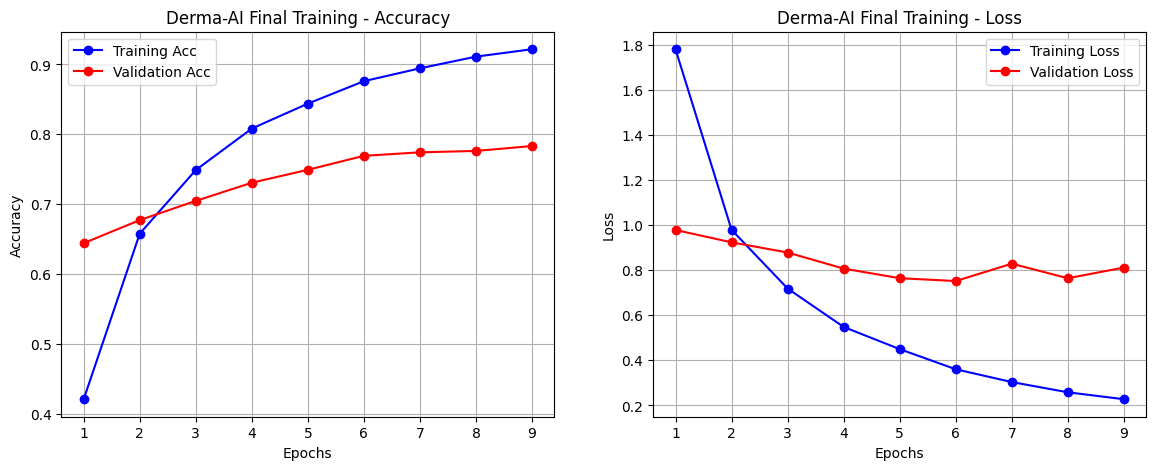

In [16]:
# CELL 15: THE PERFORMANCE DASHBOARD
import matplotlib.pyplot as plt

def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.show()

# If you have multiple history objects from different runs, 
# you can plot the most recent breakthrough run:
plot_history(history_breakthrough, "Derma-AI Final Training")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


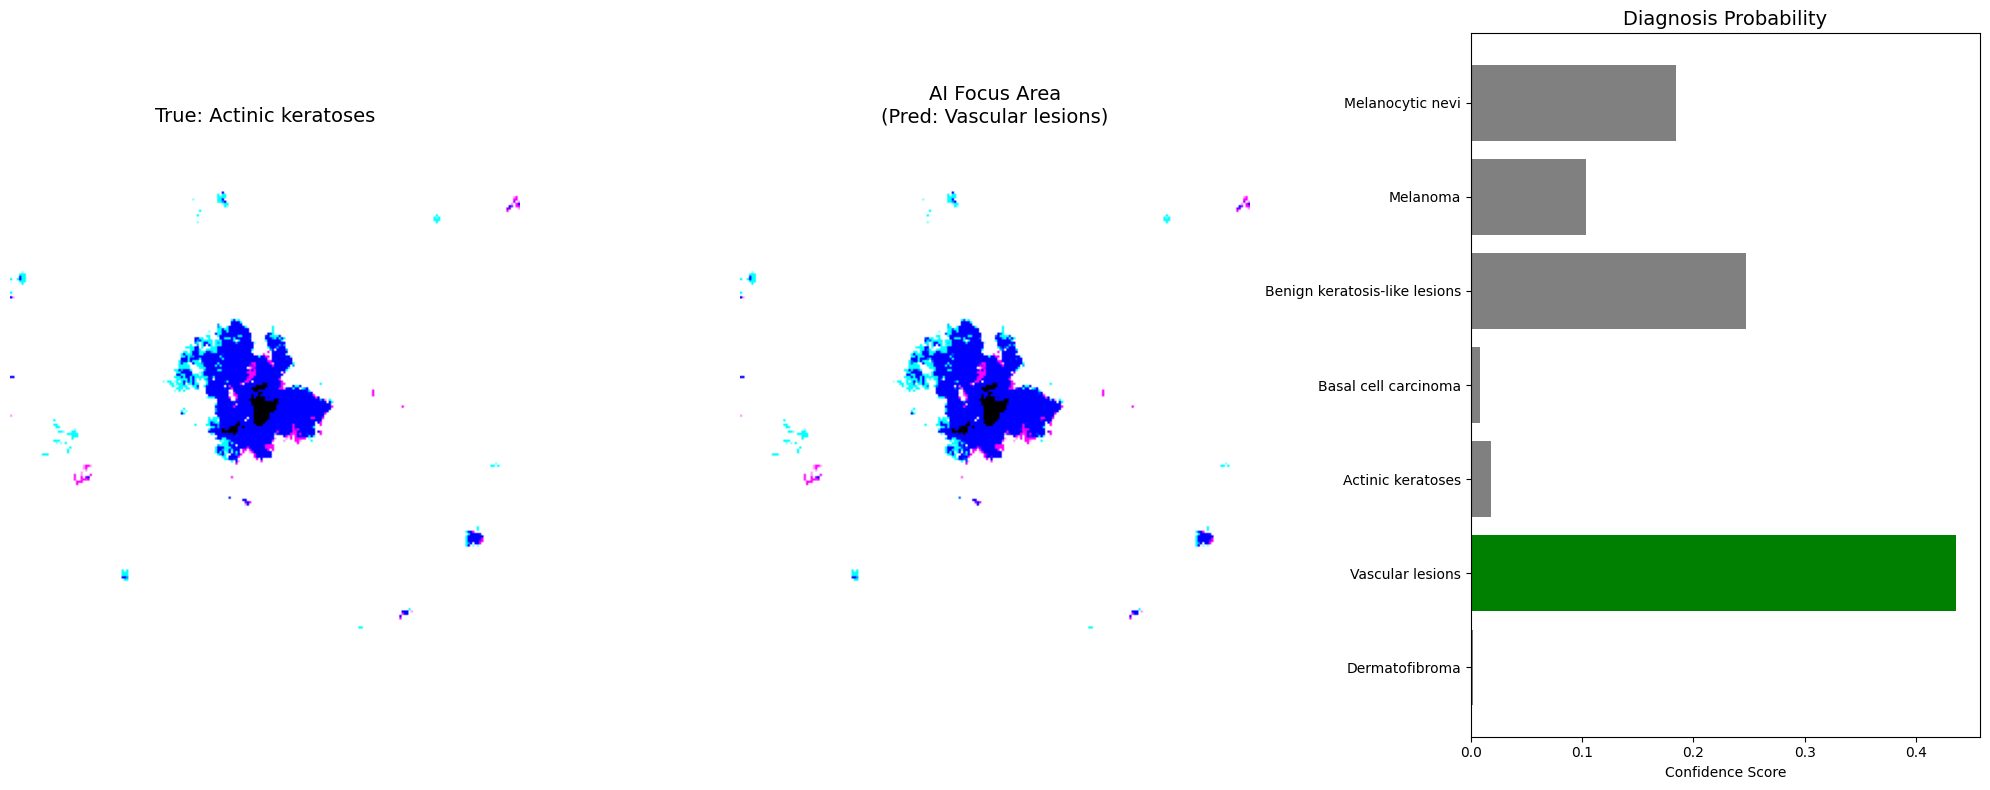

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


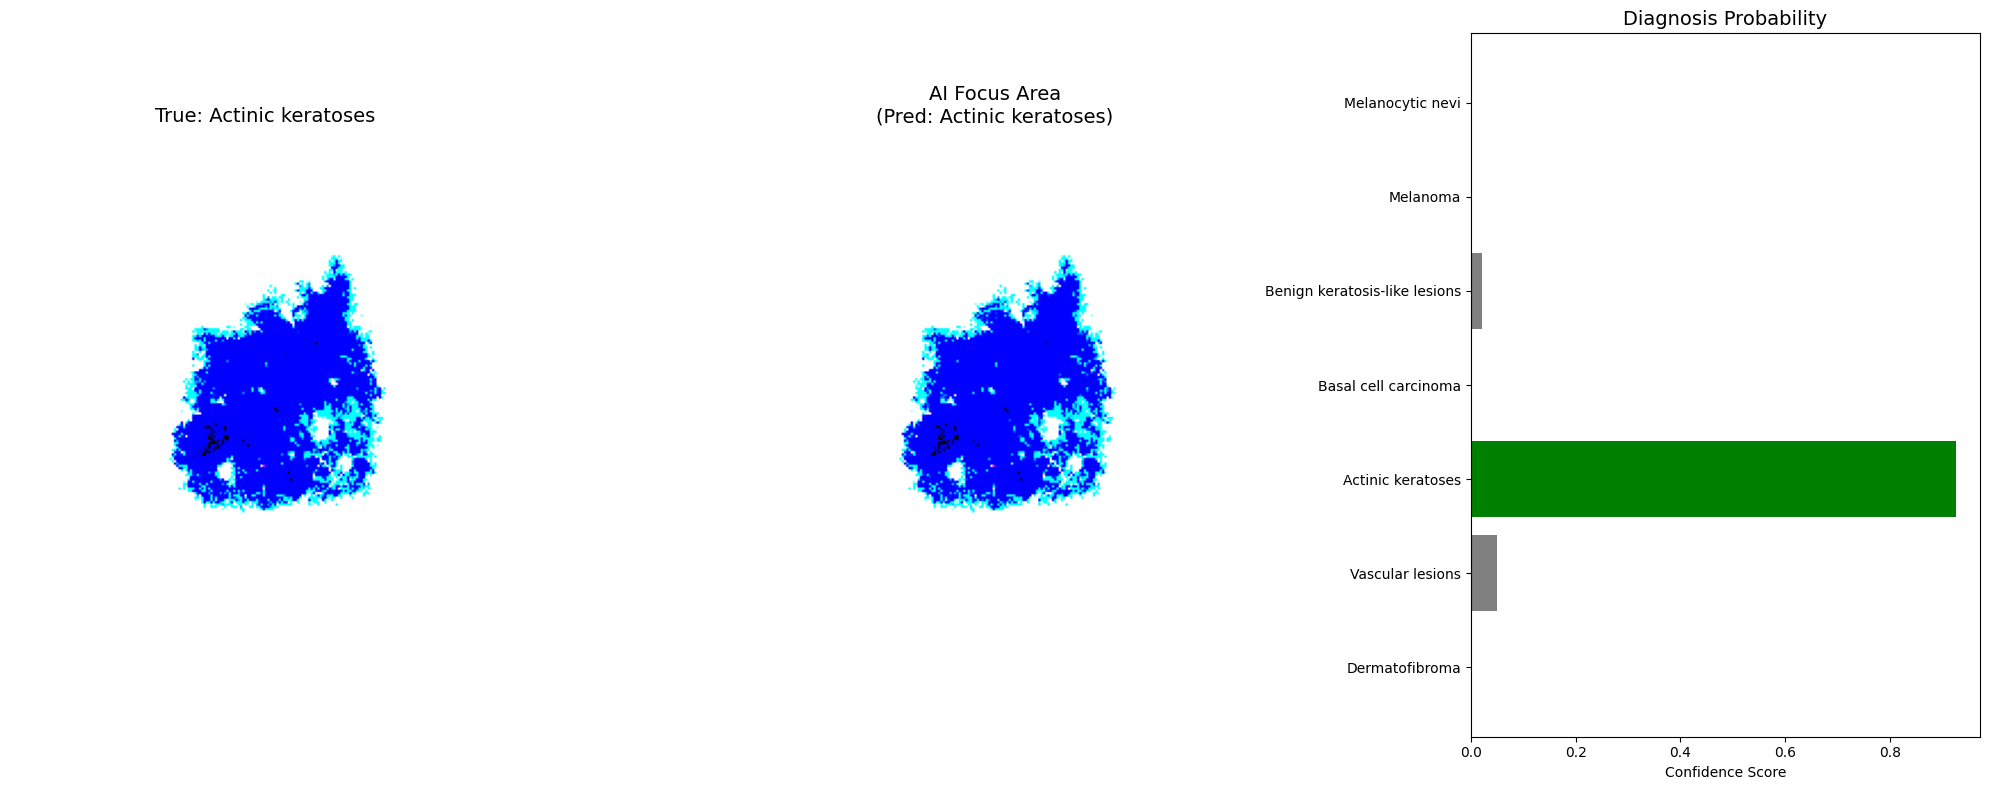

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


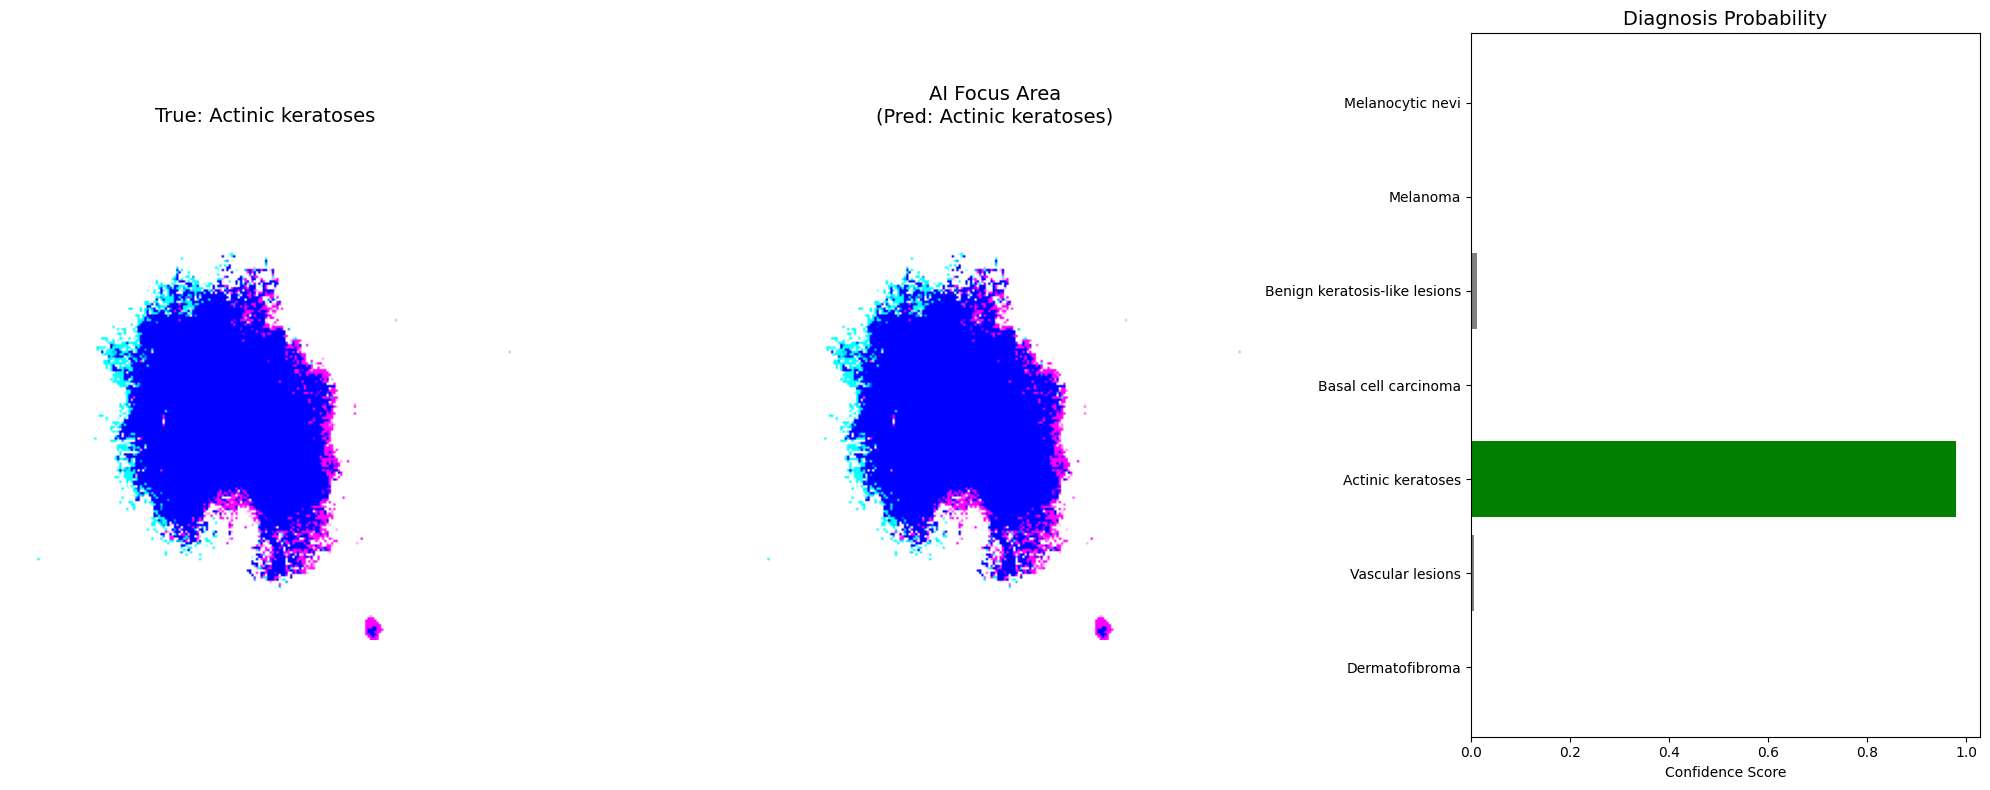

In [17]:
# CELL 16: THE DIAGNOSTIC DASHBOARD
import cv2
import matplotlib.pyplot as plt

def visualize_prediction(img_idx):
    # 1. Get image and true label
    img = test_images[img_idx]
    true_label_idx = np.argmax(test_labels[img_idx])
    true_label = list(lesion_type_dict.values())[true_label_idx]

    # 2. Get Prediction & Confidence
    img_array = np.expand_dims(img, axis=0)
    preds = model.predict(img_array, verbose=0)[0]
    pred_label_idx = np.argmax(preds)
    pred_label = list(lesion_type_dict.values())[pred_label_idx]
    
    # 3. Generate Heatmap (using the function from Cell 9/11)
    heatmap = make_gradcam_heatmap(img_array, model, 'conv5_block3_out')
    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (224, 224))
    
    # Superimpose
    superimposed_img = jet_heatmap * 0.4 + (img + 1) / 2.0
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # 4. Create the Dashboard Plot
    fig = plt.figure(figsize=(20, 8))
    
    # Subplot 1: Original
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow((img + 1) / 2.0)
    ax1.set_title(f"True: {true_label}", fontsize=14)
    ax1.axis('off')
    
    # Subplot 2: Heatmap
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(superimposed_img)
    ax2.set_title(f"AI Focus Area\n(Pred: {pred_label})", fontsize=14)
    ax2.axis('off')
    
    # Subplot 3: Confidence Bar Chart
    ax3 = fig.add_subplot(1, 3, 3)
    y_pos = np.arange(len(lesion_type_dict))
    colors = ['gray'] * 7
    colors[pred_label_idx] = 'red' if 'Melanoma' in pred_label else 'green'
    
    ax3.barh(y_pos, preds, align='center', color=colors)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(list(lesion_type_dict.values()))
    ax3.invert_yaxis()  # labels read top-to-bottom
    ax3.set_xlabel('Confidence Score')
    ax3.set_title('Diagnosis Probability', fontsize=14)

    plt.tight_layout()
    plt.show()

# Visualize the first 3 images from the current batch
for i in range(3):
    visualize_prediction(i)

In [18]:
# CELL 17: MODEL ARCHITECTURE VISUALIZATION
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model_structure.png', show_shapes=True, show_layer_names=True)
print("Model structure saved as 'model_structure.png'")

Model structure saved as 'model_structure.png'


Generating final evaluation...
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 294ms/step


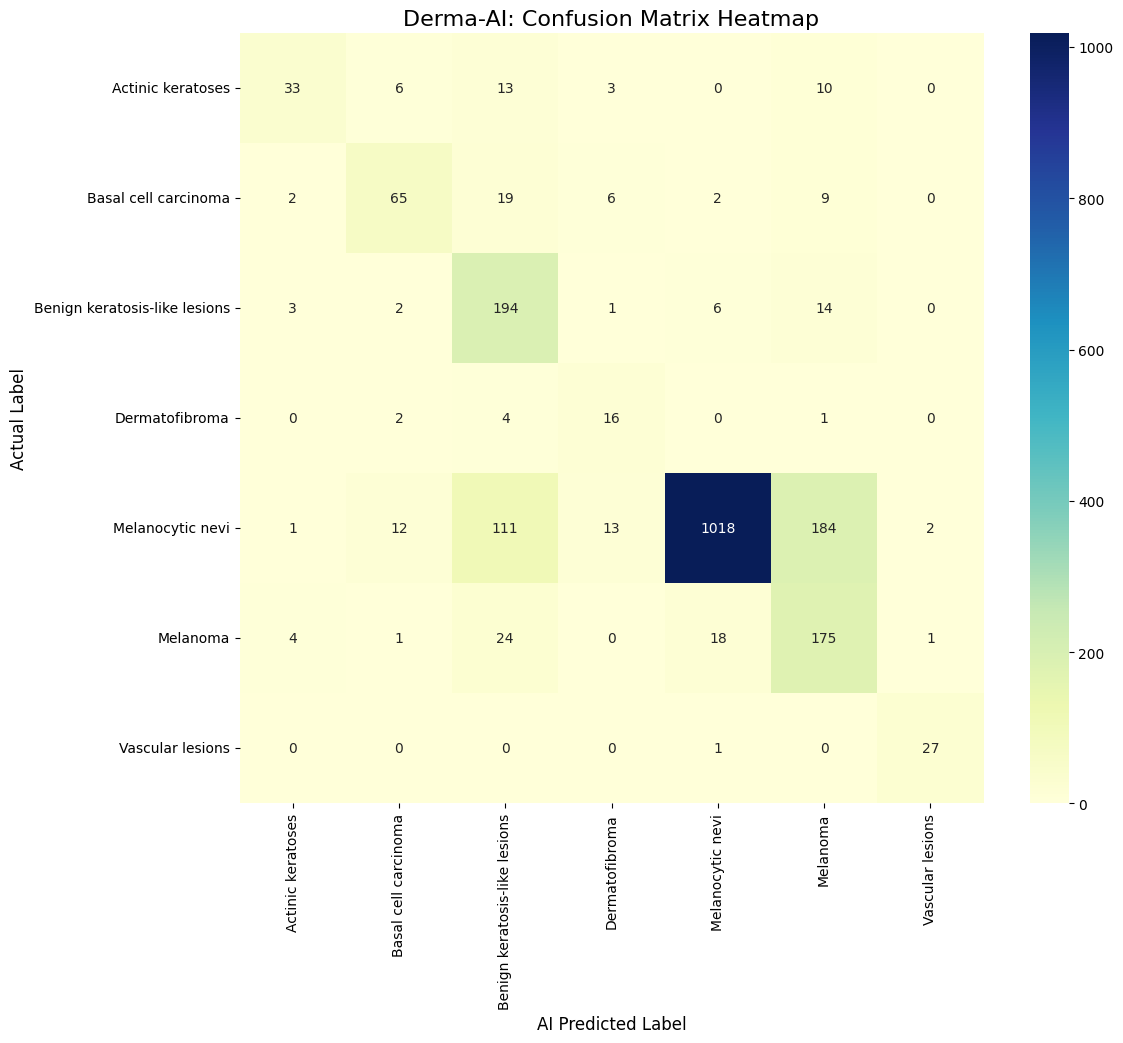


--- Detailed Classification Report ---
                               precision    recall  f1-score   support

            Actinic keratoses       0.77      0.51      0.61        65
         Basal cell carcinoma       0.74      0.63      0.68       103
Benign keratosis-like lesions       0.53      0.88      0.66       220
               Dermatofibroma       0.41      0.70      0.52        23
             Melanocytic nevi       0.97      0.76      0.85      1341
                     Melanoma       0.45      0.78      0.57       223
             Vascular lesions       0.90      0.96      0.93        28

                     accuracy                           0.76      2003
                    macro avg       0.68      0.75      0.69      2003
                 weighted avg       0.84      0.76      0.78      2003



In [19]:
# CELL 18: CONFUSION MATRIX & EVALUATION
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Get Predictions for the entire test set
print("Generating final evaluation...")
test_gen_simple.reset()
y_pred_probs = model.predict(test_gen_simple, steps=len(test_gen_simple))
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen_simple.classes

# 2. Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_gen_simple.class_indices.keys())

# 3. Plot Confusion Matrix Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Derma-AI: Confusion Matrix Heatmap', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('AI Predicted Label', fontsize=12)
plt.show()

# 4. Print detailed metrics
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 2003 validated image filenames belonging to 7 classes.


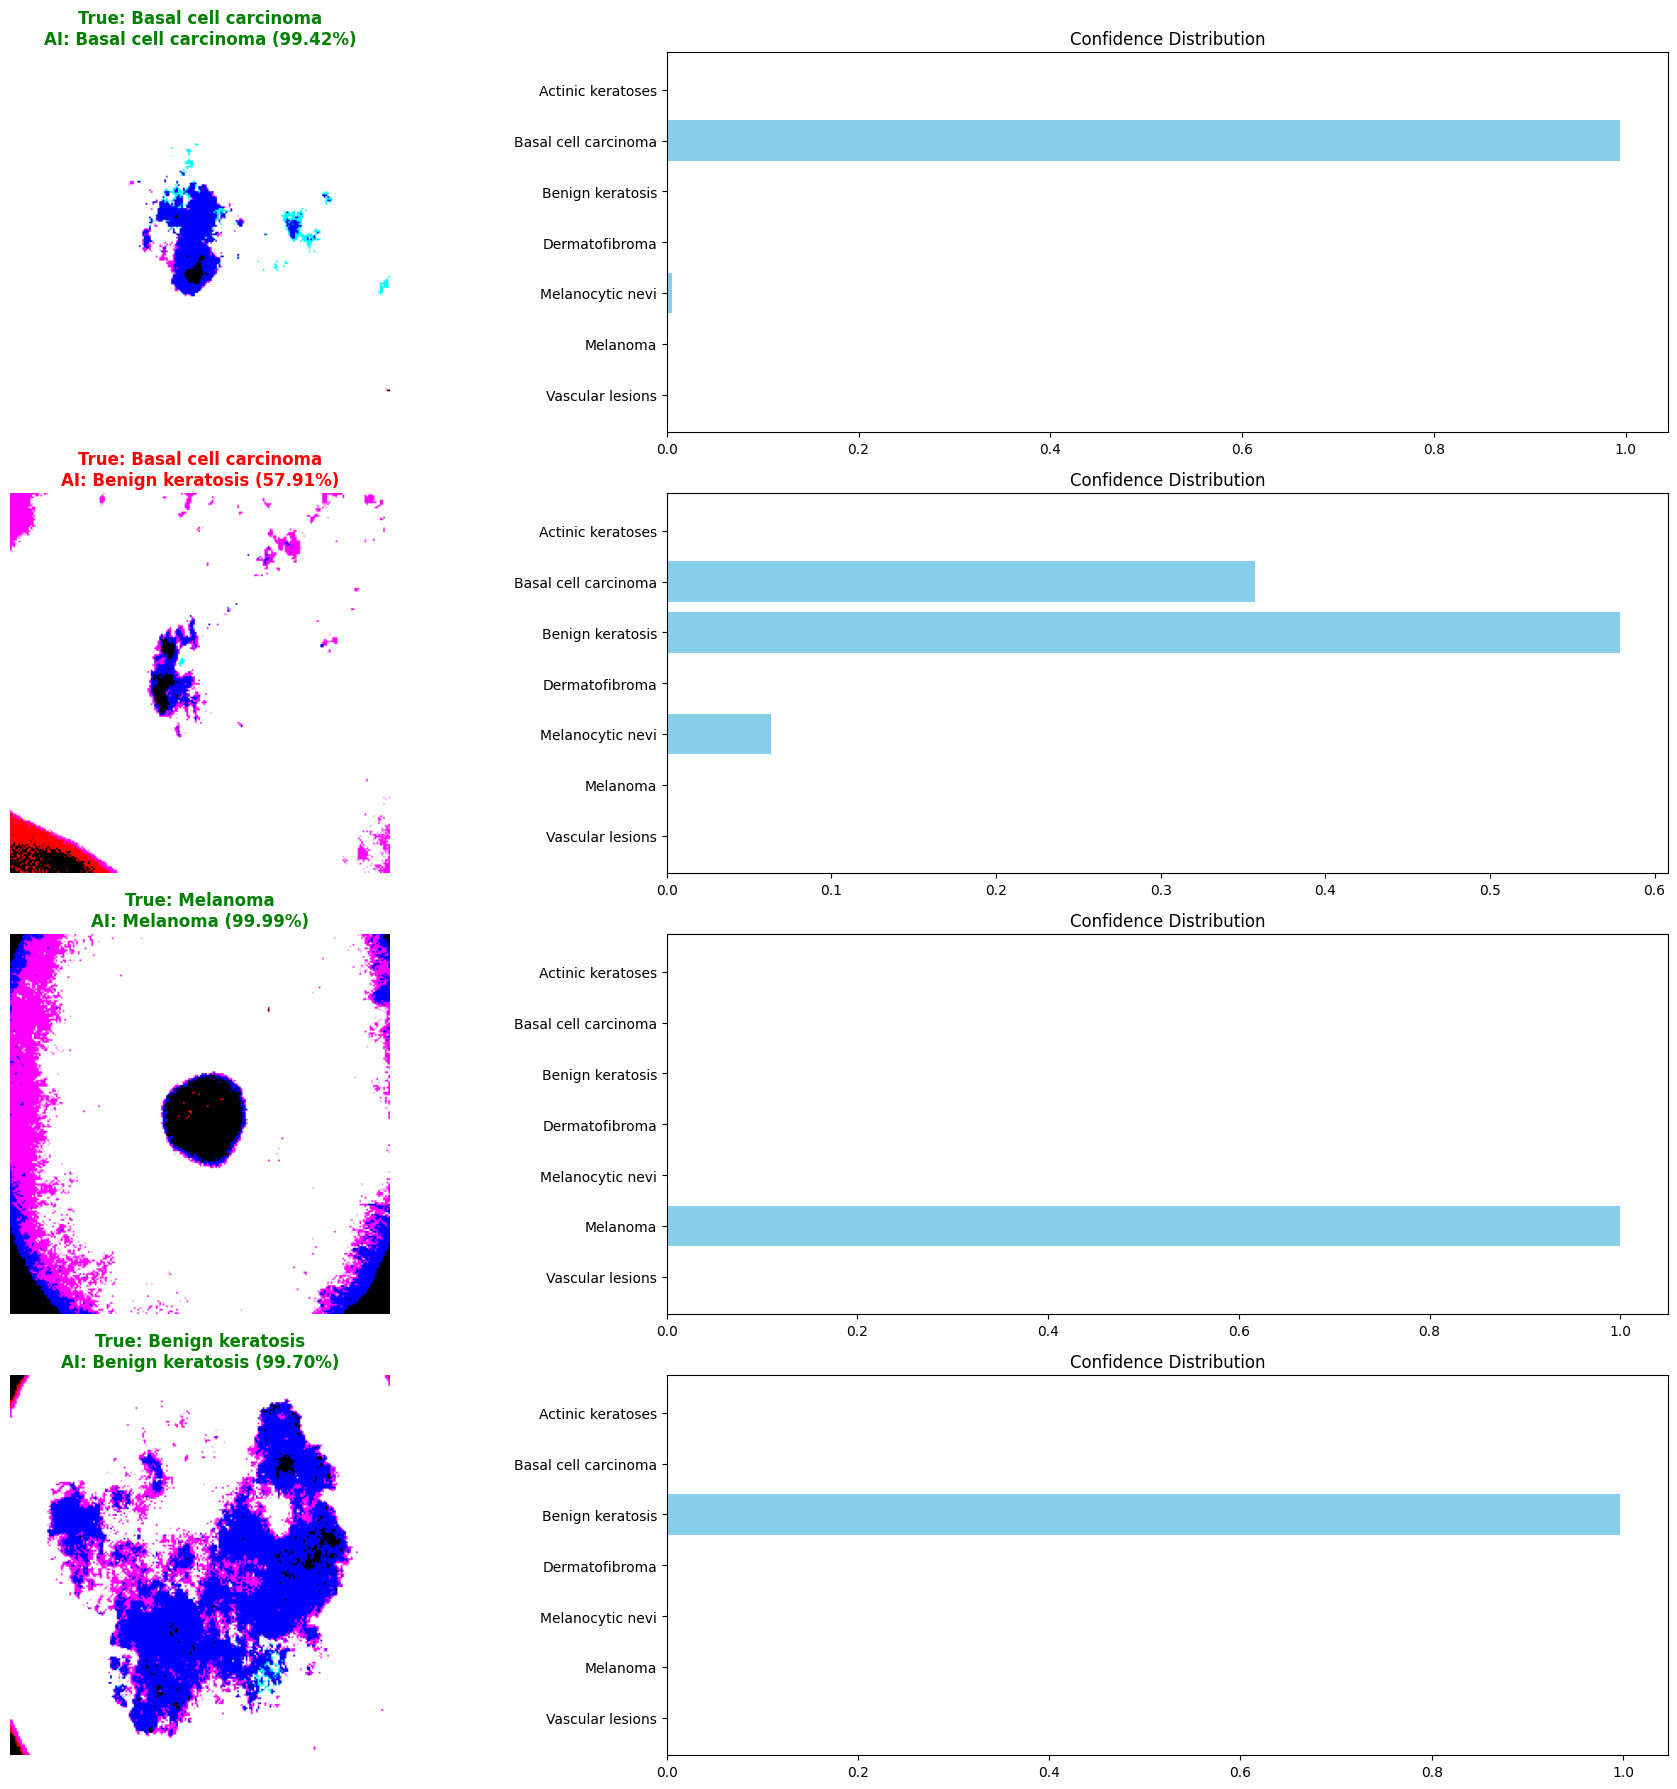

In [23]:
# CELL 19: MULTI-FOLDER DIAGNOSTIC (Part 1 + Part 2)
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# 1. Load Model (Using your uploaded path)
MODEL_PATH = '/kaggle/input/models/abhinav200417/resnet50/tensorflow2/default/1/model_best (3).h5'
model = tf.keras.models.load_model(MODEL_PATH)

# 2. Re-map ALL image paths (Scanning both folders)
metadata_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
base_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/'

df = pd.read_csv(metadata_path)

# This scans both 'ham10000_images_part_1' and 'ham10000_images_part_2'
imageid_path_dict = {os.path.splitext(f)[0]: os.path.join(root, f) 
                     for root, dirs, files in os.walk(base_dir) 
                     for f in files if f.endswith('.jpg')}

df['path'] = df['image_id'].map(imageid_path_dict)

# Map labels
lesion_type_dict = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma', 'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma', 'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions', 'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(lesion_type_dict)

# 3. Create a SHUFFLED Test Set 
# We shuffle here to ensure we get a mix of images from Part 1 and Part 2
_, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['dx'])

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='path',
    y_col='cell_type',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True  # Shuffling gives us variety from the whole test set
)

# 4. Dashboard Visualization
x_test, y_test = next(test_gen)
class_names = list(test_gen.class_indices.keys())

plt.figure(figsize=(20, 18))
for i in range(4):
    img = x_test[i]
    true_idx = np.argmax(y_test[i])
    preds = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_idx = np.argmax(preds)
    
    # Plotting
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow((img + 1) / 2.0)
    color = 'green' if true_idx == pred_idx else 'red'
    plt.title(f"True: {class_names[true_idx]}\nAI: {class_names[pred_idx]} ({preds[pred_idx]*100:.2f}%)", 
              color=color, fontsize=12, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(4, 2, 2*i + 2)
    y_pos = np.arange(len(class_names))
    plt.barh(y_pos, preds, color='skyblue')
    plt.yticks(y_pos, class_names)
    plt.gca().invert_yaxis()
    plt.title('Confidence Distribution')

plt.tight_layout()
plt.show()